In [116]:
import pandas as pd

In [117]:
data = pd.read_csv("/Mall_Customers.csv")
data.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [118]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [119]:
data['Gender'].mode()

,Gender
0,Female


In [120]:
data['Age'].mode()

,Age
0,32


In [121]:
data['Annual Income (k$)'].mode()

,Annual Income (k$)
0,54
1,78


In [122]:
data['Spending Score (1-100)'].mode()

,Spending Score (1-100)
0,42


In [123]:
custsegment = data[['Annual Income (k$)','Spending Score (1-100)']]
custsegment.head(5)

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [124]:
from sklearn.preprocessing import StandardScaler

In [125]:
scaler = StandardScaler()
custsegmentscaled = scaler.fit_transform(custsegment)
custsegmentscaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [126]:
from sklearn.cluster import KMeans

In [127]:
wcss=[]
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(custsegmentscaled)
  wcss.append(kmeans.inertia_)

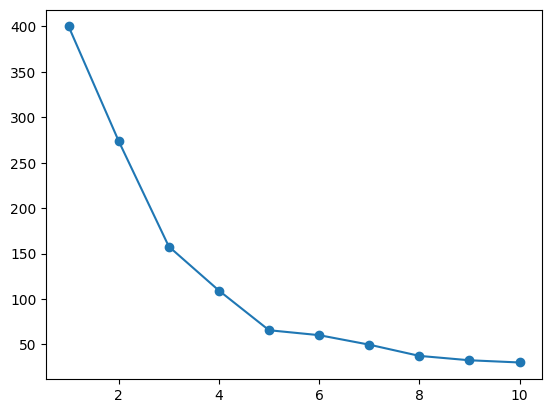

In [128]:
plt.plot(range(1,11), wcss, marker='o')

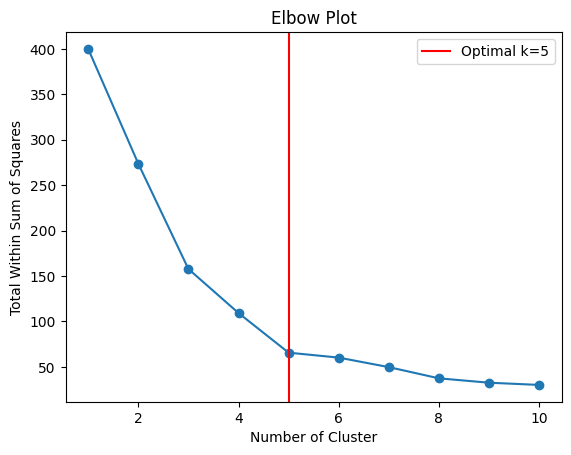

In [130]:
plt.plot(range(1,11), wcss, marker='o')
plt.axvline(x=5,
            color='red',
            linestyle='-',
            label='Optimal k=5')
plt.xlabel('Number of Cluster')
plt.ylabel('Total Within Sum of Squares')
plt.title('Elbow Plot')
plt.legend()
plt.show()

In [133]:
kmeanscluster = KMeans(n_clusters=5, random_state=42)
data['Cluster'] = kmeanscluster.fit_predict(custsegmentscaled)
data.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


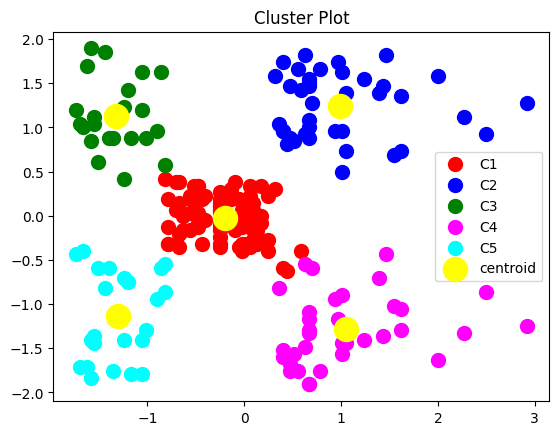

In [134]:
plt.scatter(custsegmentscaled[data['Cluster']==0, 0], custsegmentscaled[data['Cluster']==0, 1], s=100, c='red', label='C1')
plt.scatter(custsegmentscaled[data['Cluster']==1, 0], custsegmentscaled[data['Cluster']==1, 1], s=100, c='blue', label='C2')
plt.scatter(custsegmentscaled[data['Cluster']==2, 0], custsegmentscaled[data['Cluster']==2, 1], s=100, c='green', label='C3')
plt.scatter(custsegmentscaled[data['Cluster']==3, 0], custsegmentscaled[data['Cluster']==3, 1], s=100, c='magenta', label='C4')
plt.scatter(custsegmentscaled[data['Cluster']==4, 0], custsegmentscaled[data['Cluster']==4, 1], s=100, c='cyan', label='C5')
plt.scatter(kmeanscluster.cluster_centers_[:,0], kmeanscluster.cluster_centers_[:,1], s=300, c='yellow', label='centroid')
plt.title('Cluster Plot')
plt.legend()
plt.show()

In [135]:
print(kmeanscluster.cluster_centers_)

[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


In [136]:
import numpy as np

In [137]:
unique, counts = np.unique(kmeanscluster.labels_, return_counts=True)

for i, j in zip(unique, counts):
    print(f'Cluster {i+1}: {j} anggota')

Cluster 1: 81 anggota
Cluster 2: 39 anggota
Cluster 3: 22 anggota
Cluster 4: 35 anggota
Cluster 5: 23 anggota
